<a href="https://colab.research.google.com/github/Dreipfelt/ai-newsops-platform/blob/main/distilbert_finetune_newsops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DistilBERT Fine-tuning — AI NewsOps Platform
**AIA Bloc 4 — MLOps Pipeline**

⚡ Avant de lancer : `Runtime → Change runtime type → T4 GPU`

In [1]:
# ── Cellule 1 : Vérification GPU ─────────────────────────────
import torch
print(f"GPU disponible : {torch.cuda.is_available()}")
print(f"Device         : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✅ Prêt sur : {DEVICE}")

GPU disponible : True
Device         : Tesla T4
VRAM           : 15.6 GB

✅ Prêt sur : cuda


In [2]:
# ── Cellule 2 : Installation ─────────────────────────────────
!pip install -q transformers datasets kagglehub mlflow pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 143.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [5]:
from google.colab import files
import os, json

print("Upload ton fichier kaggle.json (depuis https://www.kaggle.com/settings → API → Create New Token)")
uploaded = files.upload()

# Get the first (and only) uploaded filename
if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    print(f"Fichier '{uploaded_filename}' détecté.")
    os.makedirs('/root/.config/kaggle', exist_ok=True)
    with open('/root/.config/kaggle/kaggle.json', 'wb') as f:
        f.write(uploaded[uploaded_filename]) # Use the dynamically detected filename
    os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
    print("✅ kaggle.json configuré")
else:
    print("❌ Aucun fichier n'a été uploadé.")
    print("Assure-toi d'uploader le fichier 'kaggle.json'.")

Upload ton fichier kaggle.json (depuis https://www.kaggle.com/settings → API → Create New Token)


Saving Kaggle API Token.txt to Kaggle API Token (2).txt
Fichier 'Kaggle API Token (2).txt' détecté.
✅ kaggle.json configuré


In [6]:
# ── Cellule 4 : Téléchargement & Preprocessing ───────────────
import re, json, warnings
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import kagglehub

warnings.filterwarnings('ignore')

CATEGORY_MAPPING = {
    'POLITICS': 'politics', 'THE WORLDPOST': 'politics', 'WORLD NEWS': 'politics',
    'WORLDPOST': 'politics', 'U.S. NEWS': 'politics',
    'WELLNESS': 'health_wellness', 'HEALTHY LIVING': 'health_wellness', 'TASTE': 'health_wellness',
    'ENTERTAINMENT': 'entertainment', 'COMEDY': 'entertainment', 'WEIRD NEWS': 'entertainment',
    'TRAVEL': 'lifestyle', 'STYLE & BEAUTY': 'lifestyle', 'FOOD & DRINK': 'lifestyle',
    'HOME & LIVING': 'lifestyle', 'GOOD NEWS': 'lifestyle', 'STYLE': 'lifestyle',
    'PARENTING': 'family_education', 'PARENTS': 'family_education',
    'COLLEGE': 'family_education', 'EDUCATION': 'family_education',
    'QUEER VOICES': 'media', 'BLACK VOICES': 'media', 'WOMEN': 'media',
    'MEDIA': 'media', 'LATINO VOICES': 'media',
    'BUSINESS': 'business', 'MONEY': 'business', 'FIFTY': 'business',
    'SPORTS': 'sports',
    'IMPACT': 'international', 'RELIGION': 'international',
    'GREEN': 'tech_science', 'SCIENCE': 'tech_science',
    'TECH': 'tech_science', 'ENVIRONMENT': 'tech_science',
    'ARTS': 'arts_culture', 'ARTS & CULTURE': 'arts_culture', 'CULTURE & ARTS': 'arts_culture',
    'CRIME': 'crime',
    'WEDDINGS': 'other', 'DIVORCE': 'other',
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s\-\']', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# Téléchargement
print("Téléchargement du dataset...")
import os
path = kagglehub.dataset_download('rmisra/news-category-dataset')
JSON_PATH = os.path.join(path, 'News_Category_Dataset_v3.json')

# Chargement & nettoyage
df = pd.read_json(JSON_PATH, lines=True)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.drop_duplicates(subset=['headline', 'short_description'])
df = df.dropna(subset=['headline'])
df['short_description'] = df['short_description'].fillna('')
df = df[(df['date'].dt.year >= 2012) & (df['date'].dt.year <= 2022)]
df = df[df['headline'].str.len() >= 10].reset_index(drop=True)

# Mapping
df['category'] = df['category'].map(CATEGORY_MAPPING).fillna('other')
df['text'] = df['headline'] + ' [SEP] ' + df['short_description']
df['text_clean'] = df['text'].apply(clean_text)

# Encodage
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])
id2label = {int(i): cls for i, cls in enumerate(le.classes_)}
label2id = {v: k for k, v in id2label.items()}
NUM_LABELS = len(id2label)
CLASS_NAMES = [id2label[i] for i in sorted(id2label.keys())]

# Split
train_df, temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp, test_size=0.50, random_state=42, stratify=temp['label'])

# Sauvegarder label_mapping pour le téléchargement final
Path('/content/artifacts').mkdir(exist_ok=True)
with open('/content/artifacts/label_mapping.json', 'w') as f:
    json.dump(id2label, f, indent=2)

print(f"\n✅ Dataset prêt")
print(f"   Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")
print(f"   Classes ({NUM_LABELS}) : {CLASS_NAMES}")

Téléchargement du dataset...


100%|██████████| 26.5M/26.5M [00:00<00:00, 95.6MB/s]

Extracting files...



✅ Dataset prêt
   Train : 146,113 | Val : 31,310 | Test : 31,310
   Classes (13) : ['arts_culture', 'business', 'crime', 'entertainment', 'family_education', 'health_wellness', 'international', 'lifestyle', 'media', 'other', 'politics', 'sports', 'tech_science']


In [7]:
# ── Cellule 5 : Dataset PyTorch ──────────────────────────────
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast

MAX_LENGTH = 128
BATCH_SIZE = 64   # T4 = 16GB VRAM → on peut monter à 64
MODEL_NAME = 'distilbert-base-uncased'

class NewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=MAX_LENGTH):
        self.texts     = df['text'].tolist()
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

train_ds = NewsDataset(train_df, tokenizer)
val_ds   = NewsDataset(val_df,   tokenizer)
test_ds  = NewsDataset(test_df,  tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Dataloaders prêts")
print(f"   Steps/epoch : {len(train_loader):,}")
print(f"   Batch size  : {BATCH_SIZE}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Dataloaders prêts
   Steps/epoch : 2,284
   Batch size  : 64


In [8]:
# ── Cellule 6 : Modèle + Optimizer ───────────────────────────
from transformers import DistilBertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

EPOCHS       = 3
LEARNING_RATE = 2e-5

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
).to(DEVICE)

optimizer     = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)
scheduler     = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

total_params  = sum(p.numel() for p in model.parameters())
print(f"✅ DistilBERT chargé")
print(f"   Paramètres  : {total_params:,}")
print(f"   Total steps : {total_steps:,}  |  Warmup : {warmup_steps:,}")
print(f"   Durée estimée sur T4 : ~20-25 min")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ DistilBERT chargé
   Paramètres  : 66,963,469
   Total steps : 6,852  |  Warmup : 685
   Durée estimée sur T4 : ~20-25 min


In [9]:
# ── Cellule 7 : Boucle d'entraînement ────────────────────────
from sklearn.metrics import f1_score, accuracy_score, classification_report
import time

def train_epoch(model, loader):
    model.train()
    total_loss = 0.0
    for i, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)
        optimizer.zero_grad()
        out  = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()
        if (i + 1) % 200 == 0:
            print(f"  Step {i+1}/{len(loader)} — loss: {out.loss.item():.4f}")
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labs, total_loss = [], [], 0.0
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)
        out  = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        total_loss += out.loss.item()
        preds.extend(torch.argmax(out.logits, dim=-1).cpu().numpy())
        labs.extend(labels.cpu().numpy())
    return total_loss/len(loader), f1_score(labs, preds, average='macro'), accuracy_score(labs, preds), preds, labs

history    = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': []}
best_val_f1 = 0.0
MODEL_DIR   = Path('/content/artifacts/best_model')

print(f"🚀 Début entraînement — {EPOCHS} epochs sur {DEVICE}\n")
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"{'='*50}")
    print(f"  EPOCH {epoch}/{EPOCHS}")
    print(f"{'='*50}")
    t_epoch = time.time()

    train_loss = train_epoch(model, train_loader)
    val_loss, val_f1, val_acc, _, _ = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)

    elapsed = (time.time() - t_epoch) / 60
    print(f"  Train loss : {train_loss:.4f}")
    print(f"  Val   loss : {val_loss:.4f}")
    print(f"  Val   F1   : {val_f1:.4f}  |  Acc : {val_acc:.4f}")
    print(f"  Durée      : {elapsed:.1f} min")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(MODEL_DIR)
        tokenizer.save_pretrained(MODEL_DIR)
        print(f"  ✅ Meilleur modèle sauvegardé (F1={best_val_f1:.4f})")

total_time = (time.time() - t0) / 60
print(f"\n🏁 Entraînement terminé en {total_time:.1f} min")

🚀 Début entraînement — 3 epochs sur cuda

  EPOCH 1/3
  Step 200/2284 — loss: 1.8142
  Step 400/2284 — loss: 1.1274
  Step 600/2284 — loss: 1.0088
  Step 800/2284 — loss: 0.9609
  Step 1000/2284 — loss: 0.7985
  Step 1200/2284 — loss: 0.7953
  Step 1400/2284 — loss: 0.9256
  Step 1600/2284 — loss: 0.6611
  Step 1800/2284 — loss: 0.9460
  Step 2000/2284 — loss: 0.8109
  Step 2200/2284 — loss: 0.8098
  Train loss : 1.0737
  Val   loss : 0.7845
  Val   F1   : 0.6933  |  Acc : 0.7462
  Durée      : 26.2 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Meilleur modèle sauvegardé (F1=0.6933)
  EPOCH 2/3
  Step 200/2284 — loss: 0.7831
  Step 400/2284 — loss: 0.6316
  Step 600/2284 — loss: 0.9058
  Step 800/2284 — loss: 0.6758
  Step 1000/2284 — loss: 0.9117
  Step 1200/2284 — loss: 0.6687
  Step 1400/2284 — loss: 0.6639
  Step 1600/2284 — loss: 0.8366
  Step 1800/2284 — loss: 0.5441
  Step 2000/2284 — loss: 0.6874
  Step 2200/2284 — loss: 0.5998
  Train loss : 0.6796
  Val   loss : 0.7273
  Val   F1   : 0.7105  |  Acc : 0.7627
  Durée      : 26.3 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Meilleur modèle sauvegardé (F1=0.7105)
  EPOCH 3/3
  Step 200/2284 — loss: 0.4413
  Step 400/2284 — loss: 0.4308
  Step 600/2284 — loss: 0.5536
  Step 800/2284 — loss: 0.4266
  Step 1000/2284 — loss: 0.5723
  Step 1200/2284 — loss: 0.6634
  Step 1400/2284 — loss: 0.7093
  Step 1600/2284 — loss: 0.4611
  Step 1800/2284 — loss: 0.4975
  Step 2000/2284 — loss: 0.5896
  Step 2200/2284 — loss: 0.6329
  Train loss : 0.5617
  Val   loss : 0.7322
  Val   F1   : 0.7127  |  Acc : 0.7644
  Durée      : 26.3 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Meilleur modèle sauvegardé (F1=0.7127)

🏁 Entraînement terminé en 78.9 min


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  RÉSULTATS TEST — DistilBERT (meilleur checkpoint)
                  precision    recall  f1-score   support

    arts_culture       0.61      0.61      0.61       587
        business       0.69      0.61      0.64      1370
           crime       0.65      0.59      0.62       533
   entertainment       0.76      0.75      0.76      3824
family_education       0.73      0.79      0.76      2214
 health_wellness       0.78      0.81      0.79      3995
   international       0.59      0.49      0.54       905
       lifestyle       0.84      0.86      0.85      5074
           media       0.67      0.61      0.64      2769
           other       0.86      0.88      0.87      1059
        politics       0.83      0.86      0.85      6972
          sports       0.77      0.80      0.78       761
    tech_science       0.64      0.63      0.63      1247

        accuracy                           0.77     31310
       macro avg       0.72      0.71      0.72     31310
    weighted avg 

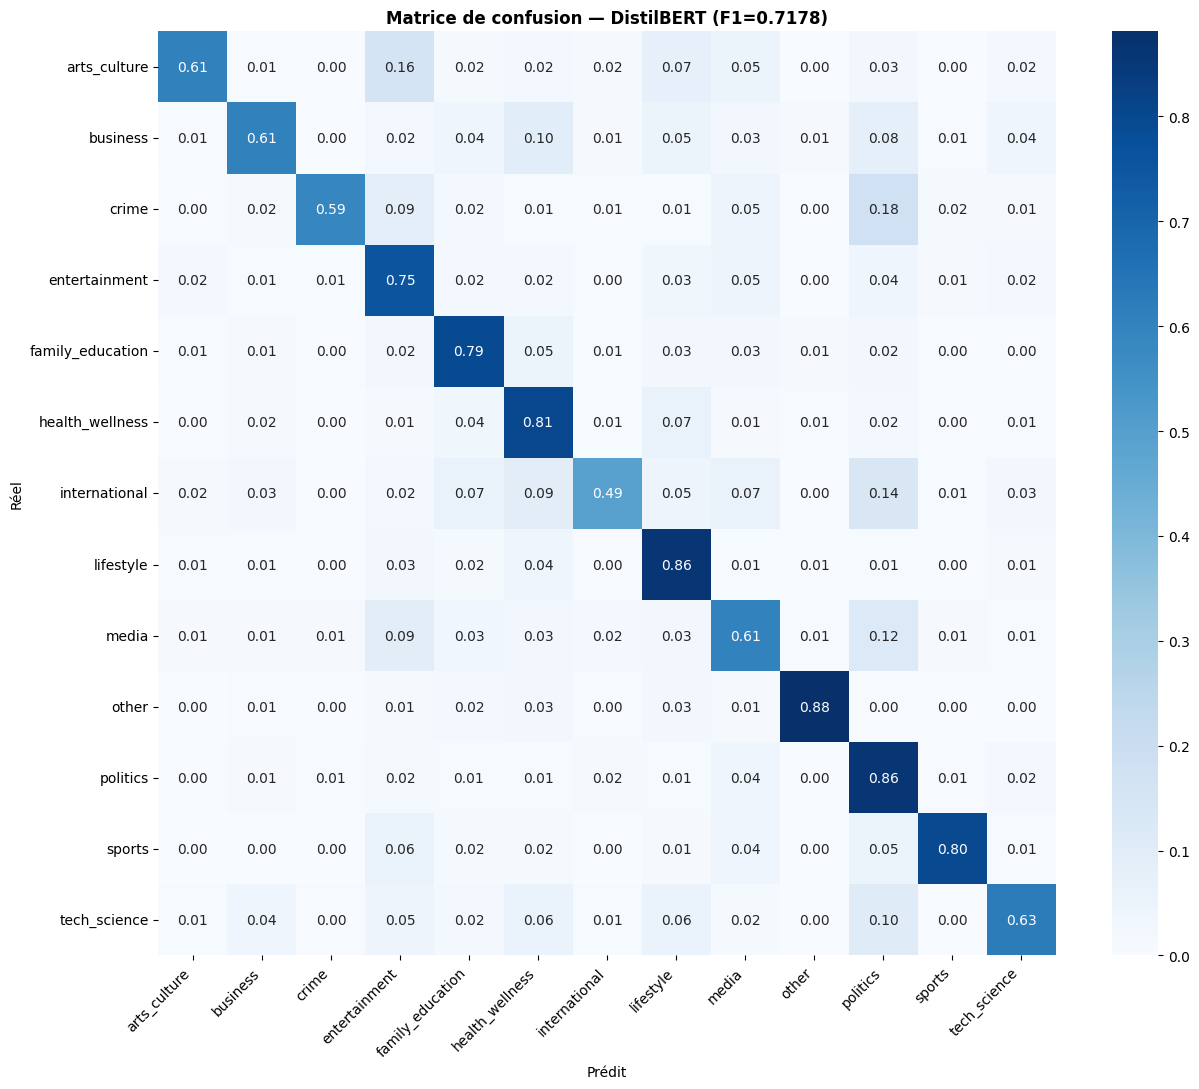

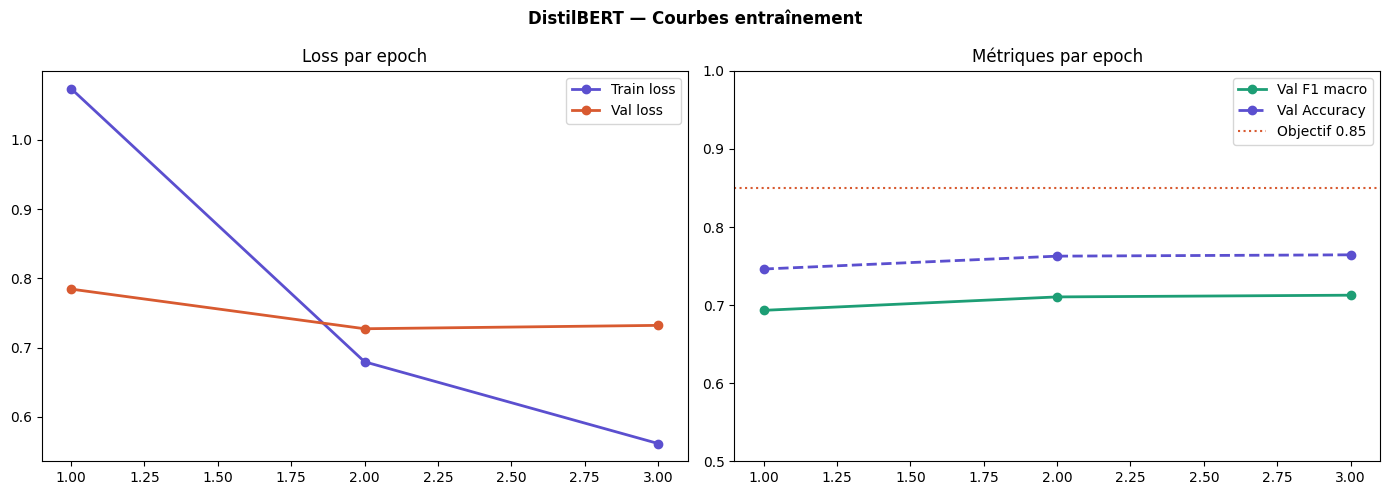

In [10]:
# ── Cellule 8 : Évaluation finale sur TEST ───────────────────
from transformers import DistilBertForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_model = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR).to(DEVICE)
test_loss, test_f1, test_acc, test_preds, test_labels = evaluate(best_model, test_loader)

print('\n' + '='*60)
print('  RÉSULTATS TEST — DistilBERT (meilleur checkpoint)')
print('='*60)
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))
print(f'  Test F1 macro  : {test_f1:.4f}')
print(f'  Test Accuracy  : {test_acc:.4f}')
print(f'  Baseline SVM   : 0.6515')
print(f'  Delta          : +{test_f1 - 0.6515:.4f} pts F1')
print('='*60)

# Matrice de confusion
cm = confusion_matrix(test_labels, test_preds, normalize='true')
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title(f'Matrice de confusion — DistilBERT (F1={test_f1:.4f})', fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('/content/artifacts/distilbert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Courbes d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, EPOCHS + 1)
axes[0].plot(epochs_x, history['train_loss'], 'o-', color='#5B4FCF', lw=2, label='Train loss')
axes[0].plot(epochs_x, history['val_loss'],   'o-', color='#D85A30', lw=2, label='Val loss')
axes[0].set_title('Loss par epoch'); axes[0].legend()
axes[1].plot(epochs_x, history['val_f1'],  'o-', color='#1D9E75', lw=2, label='Val F1 macro')
axes[1].plot(epochs_x, history['val_acc'], 'o-', color='#5B4FCF', lw=2, linestyle='--', label='Val Accuracy')
axes[1].axhline(0.85, color='#D85A30', lw=1.5, linestyle=':', label='Objectif 0.85')
axes[1].set_title('Métriques par epoch'); axes[1].legend(); axes[1].set_ylim(0.5, 1.0)
plt.suptitle('DistilBERT — Courbes entraînement', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/artifacts/distilbert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── Cellule 9 : Sauvegarde des métriques ─────────────────────
metrics = {
    'model':          'distilbert-base-uncased',
    'epochs':         EPOCHS,
    'batch_size':     BATCH_SIZE,
    'learning_rate':  LEARNING_RATE,
    'max_length':     MAX_LENGTH,
    'best_val_f1':    round(best_val_f1, 4),
    'test_f1_macro':  round(test_f1, 4),
    'test_accuracy':  round(test_acc, 4),
    'baseline_f1':    0.6515,
    'delta_f1':       round(test_f1 - 0.6515, 4),
    'num_labels':     NUM_LABELS,
    'class_names':    CLASS_NAMES,
    'history':        history,
}
with open('/content/artifacts/training_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('✅ Métriques sauvegardées → /content/artifacts/training_metrics.json')

✅ Métriques sauvegardées → /content/artifacts/training_metrics.json


In [12]:
# ── Cellule 10 : Téléchargement de tout ──────────────────────
import shutil
from google.colab import files

# Zipper le dossier artifacts (modèle + métriques + figures)
shutil.make_archive('/content/newsops_distilbert', 'zip', '/content/artifacts')
files.download('/content/newsops_distilbert.zip')

print('✅ newsops_distilbert.zip téléchargé')
print('\nContenu du zip :')
import os
for root, dirs, filenames in os.walk('/content/artifacts'):
    for fname in filenames:
        fpath = os.path.join(root, fname)
        size  = os.path.getsize(fpath) / 1e6
        print(f'  {fpath.replace("/content/artifacts/", "")}  ({size:.1f} MB)')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ newsops_distilbert.zip téléchargé

Contenu du zip :
  training_metrics.json  (0.0 MB)
  distilbert_confusion_matrix.png  (0.2 MB)
  distilbert_training_curves.png  (0.1 MB)
  label_mapping.json  (0.0 MB)
  best_model/config.json  (0.0 MB)
  best_model/tokenizer.json  (0.7 MB)
  best_model/model.safetensors  (267.9 MB)
  best_model/tokenizer_config.json  (0.0 MB)


## Après téléchargement — commandes sur ta machine

```bash
# Dézipper dans ton repo
cd ~/Documents/Jedha/Jedha/03_Data\ Science\ \ and\ \ Eng\ -\ Lead/10_Projects/ai-newsops-platform
unzip ~/Téléchargements/newsops_distilbert.zip -d models/distilbert/

# Copier les figures
cp models/distilbert/*.png reports/figures/

# Logguer dans MLflow local
python << 'EOF'
import json, mlflow
with open('models/distilbert/training_metrics.json') as f:
    m = json.load(f)
mlflow.set_experiment('news-classifier-distilbert')
with mlflow.start_run(run_name='distilbert-colab-T4'):
    mlflow.log_params({'model': m['model'], 'epochs': m['epochs'],
                       'batch_size': m['batch_size'], 'lr': m['learning_rate']})
    mlflow.log_metrics({'test_f1_macro': m['test_f1_macro'],
                        'test_accuracy': m['test_accuracy'],
                        'best_val_f1':   m['best_val_f1'],
                        'delta_vs_baseline': m['delta_f1']})
    mlflow.log_artifact('models/distilbert/distilbert_confusion_matrix.png')
    mlflow.log_artifact('models/distilbert/distilbert_training_curves.png')
print(f"MLflow mis à jour — F1={m['test_f1_macro']} | Delta={m['delta_f1']:+.4f}")
EOF

# Commit
git add models/distilbert/ reports/figures/
git commit -m "feat: DistilBERT fine-tuned on Colab T4 (F1=TBD)"
git push origin main
```